In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/predicted_human_tfs.csv")

# columns: seq_id, motif_name, random_seq, predictions

# Filter to just those motif names we're interested in
df_alt = df[df["motif_name"].str.endswith("_alt")].copy()
df_ref = df[~df["motif_name"].str.endswith("_alt")].copy()

# Strip "_alt" to match the base motif name
df_alt["base_motif"] = df_alt["motif_name"].str.replace("_alt", "", regex=False)
df_ref["base_motif"] = df_ref["motif_name"]

# Merge on seq_id and base_motif
merged = pd.merge(
    df_ref,
    df_alt,
    on=["seq_id", "base_motif"],
    suffixes=("_ref", "_alt")
)

# Compute the variant effect difference
merged["variant_effect"] = merged["predictions_ref"] - merged["predictions_alt"]


In [3]:
len(merged)

4500

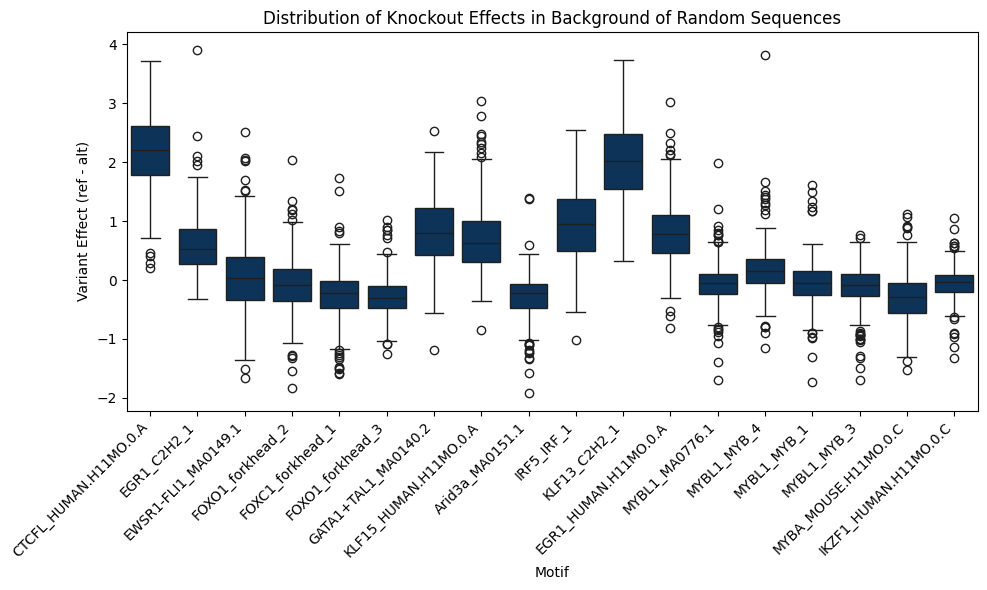

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=merged,
    x="base_motif",
    y="variant_effect",
    color='#003366'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Variant Effect (ref - alt)")
plt.xlabel("Motif")
plt.title("Distribution of Knockout Effects in Background of Random Sequences")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_all_variants.svg", format="svg")
plt.show()

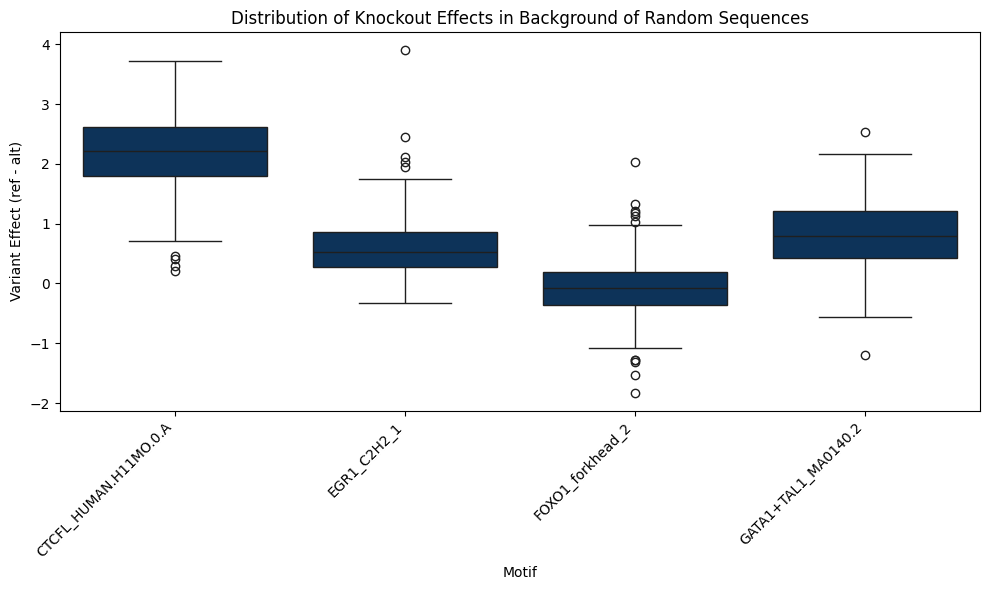

In [5]:
filters = [
    ("CTCFL_HUMAN.H11MO.0.A"),
    ("EGR1_C2H2_1"),
    ("GATA1+TAL1_MA0140.2"),
    ("FOXO1_forkhead_2")
]

# Convert to DataFrame for easy filtering
filter_df = pd.DataFrame(filters, columns=["base_motif"])

# Ensure both base_motif and random_seq are in merged
filtered = pd.merge(
    merged,
    filter_df,
    on=["base_motif"] 
)


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=filtered,
    x="base_motif",
    y="variant_effect",
    color='#003366'
)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Variant Effect (ref - alt)")
plt.xlabel("Motif")
plt.title("Distribution of Knockout Effects in Background of Random Sequences")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/range/human/distribution_k562_variants.svg", format="svg")
plt.show()
